In [1]:
#Libraries constants and utilities
#Libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

#Constants
DATA = Path("../data")

#Utilities
import sys
sys.path.append('../utilities')

from utils import (
    check_datasets_availability,
    missing_audit,
    compare_schemas,
    categorize_mood,
    analyze_mood_distribution,
    profile_numeric_columns
)
check_datasets_availability()

All datasets found, this notebook can be run without any issues.


# 1. Datasets profiling

The section has the purpose of loading each selected dataset for this project, inspecting its structure and document the findings. This is done in order to understand what each dataset actually contains first before any cleaning or analysis is done.

### DS1 - Spotify Music Dataset
This dataset contains track metadata and audio features from Spotify's API. It is originally split into two files based on track popularity a "high" file (with track_popularity $\ge$ 68) and a "low" file (with track_popularity $\le$ 68). It also includes various descriptive and audio features which will later help define mood proxies. The overlap at track_popularity == 68 in bot sets needs to examined deeper and will need a further decision on how to be handled. 

Additionally, in order to be able to interpret music listening behavious as a signal of mood, there needs to be a selection of specific audio features. This Spotify dataset conveniently includes multiple audio features which can be selected and combined with the [Thayer's model of mood](https://sites.tufts.edu/eeseniordesignhandbook/2015/music-mood-classification/) which is a psychological framework that positions emotion along two dimensions:
- **Arousal y-axis**: from calm (low) to excited (high)
- **Valence x-axis**: from sad (negative) to relaxed (positive)

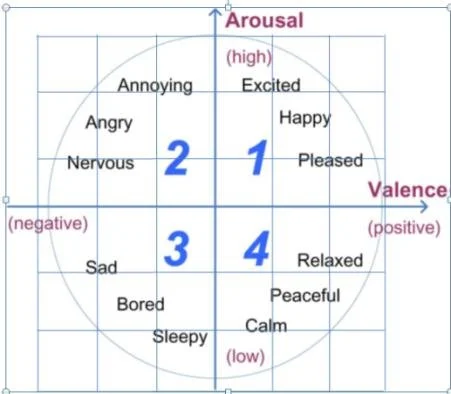

These two dimensions create a 2x2 emotional space. Any piece of music can be positioned within this space based on its audio characteristics. For this project I will define mood categories using Spotify's audio features and the actual distributions in the datasets.

In [10]:
#Loading dataset and examining basic shape
df_high = pd.read_csv(DATA/"high_popularity_spotify_data.csv")
df_low = pd.read_csv(DATA/"low_popularity_spotify_data.csv")
display(df_high.head(3))
display(df_low.head(3))
compare_schemas(df_high, df_low, "HIGH", "LOW")

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.308,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.200,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.214,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,track_album_id,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,4A8gFwqd9jTtnsNwUu3OQx,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,2c965LEDRNrXXCeBOAAwns,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,3S404OgKoVQSJ3xXrDVlp8,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition)


HIGH popularity set: (1686, 29)
LOW popularity set: (3145, 29)
Datasets schema is matching! Both sets share the same 29 columns:
['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre', 'type', 'playlist_id']

Dtype mismatches present:


,HIGH_dtype,LOW_dtype
duration_ms,int64,float64
key,int64,float64
mode,int64,float64
time_signature,int64,float64


,HIGH_dtype,LOW_dtype
acousticness,float64,float64
analysis_url,object,object
danceability,float64,float64
duration_ms,int64,float64
energy,float64,float64
id,object,object
instrumentalness,float64,float64
key,int64,float64
liveness,float64,float64
loudness,float64,float64


### Mood Categories Preliminary Definition (Based on Thayer's 2D Model)

| Mood Label | Valence | Energy | Description |
|---|---|---|---|
| Joyful/Energetic | High | High | Happy and energetic; uplifting, party music |
| Content/Peaceful | High | Low | Calm and positive; feel-good, relaxing |
| Tense/Angry | Low | High | Intense and negative; angry, frantic, aggressive |
| Sad/Melancholic | Low | Low | Somber and subdued; introspective, depressing, melancholic |

Exact thresholds will be calibrated using the median and quartile values of the data.

The following Spotify audio features will be used to position tracks within Thayer's two-dimentional space:
- **Valence:** representing musical positiveness. Direct proxy for valence axis - 0.0 (sad) to 1.0 (relaxed)
- **Energy:** representing perseptual intensity. Direct proxy for energy axis - 0.0 (calm) to 1.0 (excited)
- **Tempo:** representing beats per minute. Supporting indicator of energy - faster tempo indicates higher energy
- **Loudness:** representing overall volume (dB). Supporting indicator of energy - louder indicates more energetic
- **Danceability:** representing rhythm suitability. Supporting indicator of energy - danceable indicates more energetic

**Primary dimensions:** Valence and Energy (direct mappings to Thayer's axes)  
**Secondary indicators:** Tempo, Loudness, Danceability (used for validation and additional nuance)

In [10]:
PRIMARY_MOOD_DIMS = ["valence", "energy"]
SECONDARY_INDICATORS = ["tempo", "loudness", "danceability"]

print("PRIMARY MOOD DIMENSIONS:")
profile_numeric_columns(df_high, df_low, PRIMARY_MOOD_DIMS, "HIGH popularity set", "LOW popularity set")

print("\n\nSUPPORTING INDICATORS:")
profile_numeric_columns(df_high, df_low, SECONDARY_INDICATORS, "HIGH popularity set", "LOW popularity set")


#Preview: where would tracks fall in Thayer's space potentially?

print("\n\nMOOD SPACE CALIBRATION:")

#Using median as a rough threshold point for this preview 
valence_median_high = df_high['valence'].median()
energy_median_high = df_high['energy'].median()
valence_median_low = df_low['valence'].median()
energy_median_low = df_low['energy'].median()

print(f"\nHIGH popularity set medians:")
print(f"Valence: {valence_median_high:.3f}")
print(f"Energy: {energy_median_high:.3f}")

print(f"\nLOW popularity set medians:")
print(f"Valence: {valence_median_low:.3f}")
print(f"Energy: {energy_median_low:.3f}")

print("\n\nRough mood distribution: HIGH popularity set (using 0.5 threshold):")
df_high_temp, mood_dist_high_summary = analyze_mood_distribution(df_high, "HIGH popularity set", v_threshold=0.5, e_threshold=0.5)

print("\n\nRough mood distribution: LOW popularity set (using 0.5 threshold):")
df_low_temp, mood_dist_low_summary = analyze_mood_distribution(df_low, "LOW popularity set", v_threshold=0.5, e_threshold=0.5)

print("\n\nCOMPARISON: Mood profile on both sets")
mood_comparison = pd.DataFrame({
    'Mood': ['Joyful/Energetic', 'Content/Peaceful', 'Tense/Angry', 'Sad/Melancholic'],
    'HIGH (%)': [mood_dist_high_summary.loc[mood, 'percentage'] if mood in mood_dist_high_summary.index else 0 
                 for mood in ['Joyful/Energetic', 'Content/Peaceful', 'Tense/Angry', 'Sad/Melancholic']],
    'LOW (%)': [mood_dist_low_summary.loc[mood, 'percentage'] if mood in mood_dist_low_summary.index else 0 
                for mood in ['Joyful/Energetic', 'Content/Peaceful', 'Tense/Angry', 'Sad/Melancholic']]
})
display(mood_comparison.round(1))

PRIMARY MOOD DIMENSIONS:

HIGH popularity set:


,valence,energy
count,1686.000,1686.000
mean,0.526,0.667
std,0.236,0.185
min,0.035,0.002
25%,0.339,0.551
50%,0.528,0.689
75%,0.720,0.807
max,0.978,0.990



LOW popularity set:


,valence,energy
count,3144.000,3144.000
mean,0.458,0.544
std,0.266,0.264
min,0.030,0.000
25%,0.232,0.358
50%,0.462,0.592
75%,0.673,0.747
max,0.987,0.998




SUPPORTING INDICATORS:

HIGH popularity set:


...

,count,percentage
mood,,
Content/Peaceful,77,4.6
Joyful/Energetic,813,48.2
Sad/Melancholic,214,12.7
Tense/Angry,582,34.5




Rough mood distribution: LOW popularity set (using 0.5 threshold):

Mood distribution: LOW popularity set


,count,percentage
mood,,
Content/Peaceful,247,7.9
Joyful/Energetic,1167,37.1
Sad/Melancholic,954,30.3
Tense/Angry,777,24.7




COMPARISON: Mood profile on both sets


,Mood,HIGH (%),LOW (%)
0,Joyful/Energetic,48.2,37.1
1,Content/Peaceful,4.6,7.9
2,Tense/Angry,34.5,24.7
3,Sad/Melancholic,12.7,30.3


In [8]:
#Missing values probe
missing_audit(df_high, "HIGH set")
missing_audit(df_low, "LOW set")

HIGH set - missing values found:


,missing_count,missing_pct%
track_album_name,1,0.059


LOW set - missing values found:


,missing_count,missing_pct%
time_signature,1,0.032
speechiness,1,0.032
danceability,1,0.032
duration_ms,1,0.032
energy,1,0.032
track_href,1,0.032
mode,1,0.032
uri,1,0.032
type,1,0.032
analysis_url,1,0.032


In [6]:
#Probe into the track_popularity overlap in both sets
overlap_high = (df_high['track_popularity'] == 68).sum()
overlap_low = (df_low['track_popularity'] == 68).sum()
shared_ids = len(set(df_high["track_id"]) & set(df_low["track_id"]))

print("BOUNDARY OVERLAP RESULTS:")
print(f"HIGH file: popularity range {df_high['track_popularity'].min()}-{df_high['track_popularity'].max()}, {overlap_high} rows at == 68")
print(f"LOW file:  popularity range {df_low['track_popularity'].min()}-{df_low['track_popularity'].max()}, {overlap_low} rows at == 68")
print(f"Duplicate track_ids across both files: {shared_ids}")

BOUNDARY OVERLAP RESULTS:
HIGH file: popularity range 68-100, 124 rows at == 68
LOW file:  popularity range 11-68, 45 rows at == 68
Duplicate track_ids across both files: 43


### DS1 - Spotify Music Dataset Initial Obeservations from Profiling
#### Dataset Structure
- HIGH popularity set: 1686 tracks (track_popularity 68–100)
- LOW popularity set: 3145 tracks (track_popularity 11–68)
- Schema match confirmed: both files contain the same 29 columns
- **Dtype mismatches detected:** `duration_ms`, `key`, `mode`, `time_signature` are `int64` in HIGH popularity set but `float64` in LOW popularity set, indicating missing or null values in LOW file potentially. This needs to be reviewed during data cleaning if those attributes are meaningful for this project.

#### Data Quality Issues
**Missing values:**
- HIGH popularity set: 1 missing value in `track_album_name` (0.06%) - negligible, will be ignored most probably as album names are not relevant in this project
- LOW popularity set: 18 missing values across multiple columns (0.03% each) - this needs to be further investigated during data cleaning as mood-relevant features (valence, energy, tempo, etc.) and the row/s which are impacted must be identified.

**Boundary overlap at track_popularity == 68:**
- HIGH popularity set: 124 rows at == 68 (7.4% of HIGH)
- LOW popularity set: 45 rows at == 68 (1.4% of LOW)
- Decision required during the cleaning: establish a clean split rule (e.g., HIGH: > 68, LOW: ≤ 68)
**Duplicate track_ids:** 43 tracks appear in both files which are true duplicates

**Redundant column?** `id` and `track_id` appear identical - this needs to be further investigated during cleaning and a decision if one should be dropped.

#### Mood Dimension Findings
| Dimension | HIGH mean | LOW mean | Difference |
|-----------|-----------|----------|------------|
| **Valence** (happiness) | 0.526 | 0.458 | +0.068 |
| **Energy** (intensity) | 0.667 | 0.544 | +0.123 |
| **Tempo** (BPM) | 121.1 | 116.8 | +4.3 |
| **Loudness** (dB) | -6.7 | -10.7 | +4.0 dB |
| **Danceability** | 0.650 | 0.607 | +0.043 |

**Interpretation:** Every audio feature associated with positive and energetic mood is slightly higher in popular tracks.

#### Mood Category Distribution
When tracks are categorized into four mood quadrants (using 0.5 thresholds):

| Mood | HIGH | LOW | Observation |
|------|------|-----|-------------|
| **Joyful/Energetic** | 48.2% | 37.1% | Skewed toward popular |
| **Content/Peaceful** | 4.6% | 7.9% | Underrepresented in both |
| **Tense/Angry** | 34.5% | 24.7% | Skewed toward popular |
| **Sad/Melancholic** | 12.7% | 30.3% | **Strong pattern: popular < unpopular** |

On first glance, unpopular tracks seem much more likely to be categorized as Sad/Melancholic (30.3% vs 12.7%). However, it is very importatnt to note the sample size of both sets! The LOW popularity set is nearly twice as large, it has more statistical power to estimate proportions. The HIGH popularity set percentages are based on fewer observations and might be noisier. This observation will require further investiogation in order to determine if the difference present is aactually statistically significant or this is a result of sampling variation.


### DS2 - Top Spotify Songs in 73 Countries
This dataset contains daily chart snapshots of the top 50 Spotify tracks per country, covering 73 countries from October 2023 to June 2025. Each row represents one track on one country's chart on one specific date, and includes rank, movement, and dataset also includes additional audio features which are also present in DS1 - Spotify Music Dataset such as valence, energy, danceability, etc.).

The join key to DS1 is `spotify_id` in DS2 which is potentially matching `track_id` in DS1. I expect relatively clean data with little missing audio features and I will also verify further the above observation from first glance about the matching key `spotify_id`. 

NOTE: this dataset is much larger that the rest of the datasets (486.297MB) and operations might take a while.

In [11]:
#Loading dataset and examining basic shape
ds2 = pd.read_csv(DATA / "universal_top_spotify_songs.csv")
print(f"Loaded: {ds2.shape[0]:,} rows, {ds2.shape[1]} columns")

Loaded: 2,110,316 rows, 25 columns


In [8]:
print("Columns:", ds2.columns.tolist())
display(ds2.dtypes.to_frame(name="dtype"))
display(ds2.head(3))

Columns: ['spotify_id', 'name', 'artists', 'daily_rank', 'daily_movement', 'weekly_movement', 'country', 'snapshot_date', 'popularity', 'is_explicit', 'duration_ms', 'album_name', 'album_release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


,dtype
spotify_id,object
name,object
artists,object
daily_rank,int64
daily_movement,int64
weekly_movement,int64
country,object
snapshot_date,object
popularity,int64
is_explicit,bool


,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,Alex Warren,1,1,0,NaN,2025-06-11,95,False,...,2,-6.141,1,0.0600,0.704000,0.000007,0.0550,0.391,168.115,3
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,Sabrina Carpenter,2,-1,48,NaN,2025-06-11,89,True,...,7,-5.087,1,0.0572,0.122000,0.000000,0.3170,0.811,123.010,4
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,sombr,3,0,1,NaN,2025-06-11,98,False,...,1,-2.291,1,0.0301,0.000094,0.000088,0.0929,0.235,92.855,4


In [13]:
# snapshot_date validation as it shows as dtype = object
print("snapshot_date dtype:", ds2["snapshot_date"].dtype)
print("Sample values:", ds2["snapshot_date"].head(3).tolist())

#This needs to be noted down for the cleaning part as the snapshot_date might need to be converted to dtype datetime!

snapshot_date dtype: object
Sample values: ['2025-06-11', '2025-06-11', '2025-06-11']


In [28]:
#Check for missing values - adding additional validation
missing_audit(ds2, "DS2")

null_country_rows = ds2[ds2["country"].isnull()]
print(f"Rows with null country: {len(null_country_rows):,}")
print("Sample of null-country rows:")
display(null_country_rows[["spotify_id", "name", "daily_rank", "country", "snapshot_date", "valence", "energy", "tempo", "loudness", "danceability"]].head(5))

DS2 - missing values found:


,missing_count,missing_pct%
name,30,0.001
artists,29,0.001
country,28908,1.370
album_name,822,0.039
album_release_date,659,0.031


Rows with null country: 28,908
Sample of null-country rows:


,spotify_id,name,daily_rank,country,snapshot_date,valence,energy,tempo,loudness,danceability
0,2RkZ5LkEzeHGRsmDqKwmaJ,Ordinary,1,NaN,2025-06-11,0.391,0.694,168.115,-6.141,0.368
1,42UBPzRMh5yyz0EDPr6fr1,Manchild,2,NaN,2025-06-11,0.811,0.685,123.010,-5.087,0.731
2,0FTmksd2dxiE5e3rWyJXs6,back to friends,3,NaN,2025-06-11,0.235,0.723,92.855,-2.291,0.436
3,7so0lgd0zP2Sbgs2d7a1SZ,Die With A Smile,4,NaN,2025-06-11,0.498,0.601,157.964,-7.727,0.519
4,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,5,NaN,2025-06-11,0.438,0.507,104.978,-10.171,0.747


In [20]:
#Date range and country codes coverage check
print("Date coverage:")
print(f"Earliest snapshot: {ds2['snapshot_date'].min()}")
print(f"Latest snapshot: {ds2['snapshot_date'].max()}")
print(f"Unique dates: {ds2['snapshot_date'].nunique()}")

print("\nCountry coverage:")
print(f"Unique country codes (excluding nulls): {ds2['country'].nunique()}")
print(f"Country list: {sorted(ds2['country'].dropna().unique().tolist())}")

Date coverage:
Earliest snapshot: 2023-10-18
Latest snapshot: 2025-06-11
Unique dates: 583

Country coverage:
Unique country codes (excluding nulls): 72
Country list: ['AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BO', 'BR', 'BY', 'CA', 'CH', 'CL', 'CO', 'CR', 'CZ', 'DE', 'DK', 'DO', 'EC', 'EE', 'EG', 'ES', 'FI', 'FR', 'GB', 'GR', 'GT', 'HK', 'HN', 'HU', 'ID', 'IE', 'IL', 'IN', 'IS', 'IT', 'JP', 'KR', 'KZ', 'LT', 'LU', 'LV', 'MA', 'MX', 'MY', 'NG', 'NI', 'NL', 'NO', 'NZ', 'PA', 'PE', 'PH', 'PK', 'PL', 'PT', 'PY', 'RO', 'SA', 'SE', 'SG', 'SK', 'SV', 'TH', 'TR', 'TW', 'UA', 'US', 'UY', 'VE', 'VN', 'ZA']


In [23]:
#Duplication check
print("Duplicate check:")
print(f"Fully duplicate rows: {ds2.duplicated().sum()}")

#Checking if the same song appears multiple times in the same country for the same day
natural_key_dups = ds2.duplicated(subset=["spotify_id", "country", "snapshot_date"]).sum()
print(f"Duplicates on (spotify_id, country, snapshot_date): {natural_key_dups}")


Duplicate check:
Fully duplicate rows: 0
Duplicates on (spotify_id, country, snapshot_date): 0


In [33]:
#Checking on DS2 spotify_id vs DS1 track_id if they are the same
print(f"'spotify_id' column present: {'spotify_id' in ds2.columns}")
print(f"Null spotify_ids: {ds2['spotify_id'].isnull().sum()}")
print(f"Unique track IDs in DS2: {ds2['spotify_id'].nunique():,}")

ds1_all_ids = set(df_high["track_id"]) | set(df_low["track_id"])
ds2_ids = set(ds2["spotify_id"].dropna())

matched = len(ds2_ids & ds1_all_ids)
total_ds2 = len(ds2_ids)

print(f"\nUnique track IDs in DS1 (both files): {len(ds1_all_ids):,}")
print(f"DS2 tracks found in DS1: {matched:,}")
print(f"Match rate: {matched / total_ds2 * 100:.1f}%")
print(f"DS2 tracks NOT in DS1: {total_ds2 - matched:,}")

MOOD_FEATURES = ["valence", "energy", "tempo", "loudness", "danceability"]
sample_ids = list(ds2_ids & ds1_all_ids)[:10]

ds1_sample = pd.concat([df_high, df_low])[["track_id", "track_name", "track_artist"] + MOOD_FEATURES].drop_duplicates("track_id")
ds1_sample = ds1_sample[ds1_sample["track_id"].isin(sample_ids)]

ds2_sample = ds2[ds2["spotify_id"].isin(sample_ids)][["spotify_id", "name", "artists"] + MOOD_FEATURES].drop_duplicates("spotify_id")

comparison = ds1_sample.merge(ds2_sample, left_on="track_id", right_on="spotify_id", suffixes=(" DS1", " DS2"))

print("\nTrack name and artist verification:")
display(comparison[["track_id", "track_name", "name", "track_artist", "artists"]]
        .rename(columns={"track_id": "id", "track_name": "DS1 name", "name": "DS2 name", "track_artist": "DS1 artist", "artists": "DS2 artist"}))

print("\nAudio feature comparison:")
feat_cols = ["track_name"] + [c for f in MOOD_FEATURES for c in (f"{f} DS1", f"{f} DS2")]
display(comparison[feat_cols].rename(columns={"track_name": "track"}).round(4))

'spotify_id' column present: True
Null spotify_ids: 0
Unique track IDs in DS2: 24,983

Unique track IDs in DS1 (both files): 4,495
DS2 tracks found in DS1: 747
Match rate: 3.0%
DS2 tracks NOT in DS1: 24,236

Track name and artist verification:


,id,DS1 name,DS2 name,DS1 artist,DS2 artist
0,0WbMK4wrZ1wFSty9F7FCgu,"Good Luck, Babe!","Good Luck, Babe!",Chappell Roan,Chappell Roan
1,2FQrifJ1N335Ljm3TjTVVf,A Bar Song (Tipsy),A Bar Song (Tipsy),Shaboozey,Shaboozey
2,1i6N76fftMZhijOzFQ5ZtL,Psycho Killer - 2005 Remaster,Psycho Killer - 2005 Remaster,Talking Heads,Talking Heads
3,1qIwin7JMVuX70qN6wD8ww,It's Up (feat. Young Thug & 21 Savage),It's Up (feat. Young Thug & 21 Savage),"Drake, Young Thug, 21 Savage","Drake, Young Thug, 21 Savage"
4,1Bb422wJR14f7sA77gGs0V,Brindis,Brindis,"Duki, Headie One","Duki, Headie One"
5,6PhRhocBXP4y7NpciGmzra,Después De La 1,Después De La 1,"Cris Mj, FloyyMenor, LOUKI","Cris Mj, FloyyMenor, LOUKI"
6,59nOXPmaKlBfGMDeOVGrIK,WAIT FOR U (feat. Drake & Tems),WAIT FOR U (feat. Drake & Tems),"Future, Drake, Tems","Future, Drake, Tems"
7,2q0wKlSmIWLdpCwwKjLPxZ,Presidente,Presidente,"Gabito Ballesteros, Natanael Cano, Luis R Conr...","Gabito Ballesteros, Natanael Cano, Luis R Conr..."
8,3ncCdwV4rnFY9YNzsh4KGo,Metro,Metro,"Hotkeed, Yo X","Hotkid, Yo X"
9,2j8n2hpZlEMvtrjJ7n0ZIy,Bad Girl (feat. Asake),Bad Girl (feat. Asake),"Wizkid, Asake","Wizkid, Asake"



Audio feature comparison:


,track,valence DS1,valence DS2,energy DS1,energy DS2,tempo DS1,tempo DS2,loudness DS1,loudness DS2,danceability DS1,danceability DS2
0,"Good Luck, Babe!",0.785,0.785,0.582,0.582,116.712,116.712,-5.960,-5.960,0.700,0.700
1,A Bar Song (Tipsy),0.604,0.604,0.709,0.709,81.012,81.012,-4.950,-4.950,0.722,0.722
2,Psycho Killer - 2005 Remaster,0.942,0.942,0.521,0.521,123.118,123.118,-8.123,-8.123,0.721,0.721
3,It's Up (feat. Young Thug & 21 Savage),0.294,0.294,0.723,0.723,139.942,139.942,-4.881,-4.881,0.783,0.783
4,Brindis,0.616,0.616,0.637,0.637,135.055,135.055,-6.149,-6.149,0.851,0.851
5,Después De La 1,0.528,0.528,0.581,0.581,99.973,99.973,-5.091,-5.091,0.805,0.805
6,WAIT FOR U (feat. Drake & Tems),0.339,0.339,0.642,0.642,83.389,83.389,-4.474,-4.474,0.463,0.463
7,Presidente,0.380,0.380,0.821,0.821,104.044,104.044,-5.695,-5.695,0.721,0.721
8,Metro,0.786,0.786,0.917,0.917,120.065,120.065,-4.819,-4.819,0.870,0.870
9,Bad Girl (feat. Asake),0.644,0.644,0.622,0.622,111.998,111.998,-5.452,-5.452,0.878,0.878


### DS2 - Top Spotify Songs in 73 Countries Initial Observations from Profiling
#### Dataset Structure
- Rows: 2,110,316 across 25 columns
- Date coverage: 583 daily snapshots from 2023-10-18 to 2025-06-11
- Country coverage: 72 unique country codes found out of [249 official ISO 3166-1 alpha-2 country codes](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-2) currently defined
- All audio feature columns (valence, energy, danceability, loudness, tempo, etc.) loaded as float64 with consistent types, no mismatches
- `snapshot_date` loaded as object (string). ISO format (YYYY-MM-DD) is still sortable so string min/max returns correct date boundaries, but datetime arithmetic and filtering will require conversion to datetime 

#### Data Quality Issues
**Missing values:**
- `country`: 28,908 rows (1.37%) 
- `album_name`: 822 rows (0.04%) - not used in mood analysis, negligible
- `album_release_date`: 659 rows (0.03%) - not used in mood analysis, negligible
- `name`, `artists`: 30 and 29 rows respectively - negligible
- No missing values in any audio feature column or in `spotify_id`

**Null country rows:**
Inspecting the 28,908 null-country rows shows they have valid ranks (1–50), complete audio features which is critical for this project, and valid dates. There is a possibility that these entries represent a global chart with no country assignment, but the dataset contains no explicit label to confirm this. They will be excluded from country-level analysis and preserved separately.

**Duplicate check:**
Zero fully duplicate rows. Zero duplicates on the natural key (spotify_id, country, snapshot_date), confirming no track appears twice on the same country chart on the same day. 

#### Join Key Findings
**Match rate - DS2 spotify_id vs DS1 track_id:**

| | Count |
|---|---|
| Unique track IDs in DS2 | 24,983 |
| Unique track IDs in DS1 (both files) | 4,495 |
| Matched (DS2 found in DS1) | 747 |
| Match rate | 3.0% |
| Unmatched DS2 IDs | 24,236 |

**Critical findings:** 
- Joining DS2 to DS1 for audio features would discard 97% of the charting data. This join is also unnecessary after profiling, DS2 already includes all mood-relevant audio features directly on every row which removes the need for DS1 joining.
- `snapshot_date` must be converted to `datetime64` before any date-based filtering or seasonal aggregation.

**Revised project direction decision:**
- DS2 will be the primary data source for Experiments 1 and 2 - used directly, no join needed with DS1 
- Mood distribution analysis will be performed on the cleaned DS2 dataset, replacing the DS1 preliminary distribution - DS2 has 24,983 unique tracks which provides a significantly broader and more representative sample

**Semantic verification:** A sample of 10 matched IDs was compared side-by-side. Track names match exactly in all 10 cases. Artist names match in 9 of 10 - one minor discrepancy ("Hotkeed" in DS1 vs "Hotkid" in DS2) likely reflects a data entry inconsistency at source rather than a wrong ID match. The join key is semantically consistent overall including the audio features used for mood distribution.